# Project 3: Discrete logistic growth

MCSB Bootcamp — Mathematical and Computational Track

Jun Allard

## Model statement

Suppose a rabbit colony has a population $x(n)$ at month $n$, where $x$
is measured in thousands. If the population were growing in an unbounded
environment, the population obeys

$$x(n+1) = x(n) + r \cdot x(n)$$

where $r$ is the per-capita growth rate. Suppose instead the population
is in a bounded environment (like an island), so growth is limited and
the population obeys

$$x(n+1) = x(n) + r \left( 1 - \frac{x(n)}{K}\right) x(n)$$

where $K$ is a parameter we refer to as the carrying capacity.

## Part I

Suppose $r=0.1$ and $K=0.6$.

a.  According to your intuition, what population sizes are *steady
    states*, meaning that if the population had that value at time
    $n=0$, then it would remain at that value?

In [ ]:
# x(1) = 0
# x(1) = 0.6

b.  Sketch your intuition for the population $x(t)$ from a starting
    population $x(1)=0.2$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Part II

Write code to solve the dynamical system, and answer the following
questions:

c.  Suppose $r=0.1$ and $K=0.6$. Generate time series of the populations
    for a few starting populations $x(1)$. Does it match your intuition?

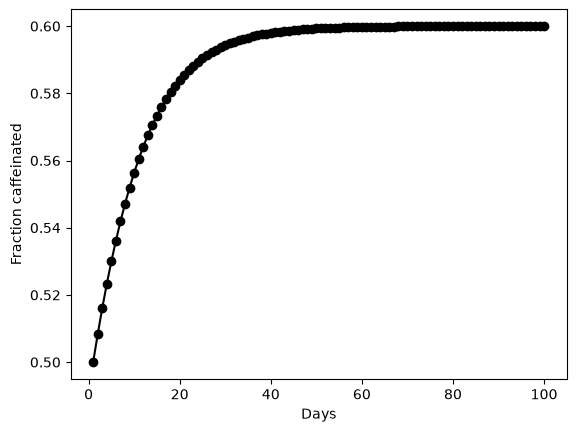

In [2]:
N = 10  # number of scoops in each jar
r = 0.1 # rate of growth
K = 0.6 # carrying capacity
n_max = 10 * N  # max number of days to simulate

x = np.zeros(n_max)  # fraction caffeinated

x[0] = 0.5

for n in range(1, n_max):

    x[n] = x[n-1] + r*(1-(x[n-1]/K))*x[n-1]

# finished loop through days

days = np.arange(1, n_max + 1)

fig, ax = plt.subplots()
ax.plot(days, x, "-ok")
ax.set_ylabel("Fraction caffeinated")
ax.set_xlabel("Days")
plt.show()


d.  Suppose $r=2.1$ and $K=0.6$. Generate time series of the populations
    for a few starting populations $x(1)$.

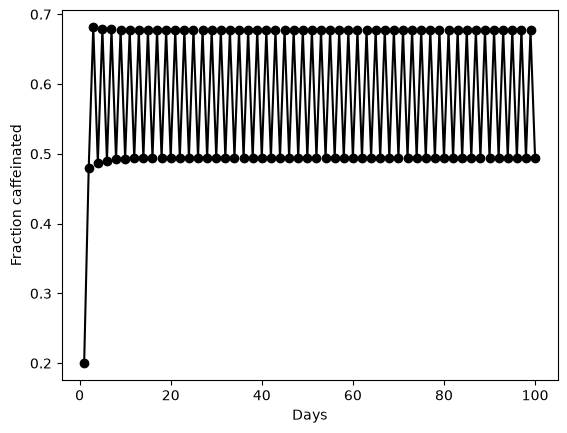

In [3]:
# Your code here. BECAUSE THE RATE IS LARGE, THE POPULATION OVERSHOOTS
N = 10  # number of scoops in each jar
r = 2.1 # rate of growth
K = 0.6 # carrying capacity
n_max = 10 * N  # max number of days to simulate

x = np.zeros(n_max)  # fraction caffeinated

x[0] = 0.2

for n in range(1, n_max):

    x[n] = x[n-1] + r*(1-(x[n-1]/K))*x[n-1]

# finished loop through days

days = np.arange(1, n_max + 1)

fig, ax = plt.subplots()
ax.plot(days, x, "-ok")
ax.set_ylabel("Fraction caffeinated")
ax.set_xlabel("Days")
plt.show()

## Part III

In a discrete-time dynamical system, if the population cycles between
two values, the solution is called a two-cycle. Cycling between $N$
values is called an $N$-cycle.

e.  Check that at $r=2.5$ and $K=0.6$ there is a 4-cycle.

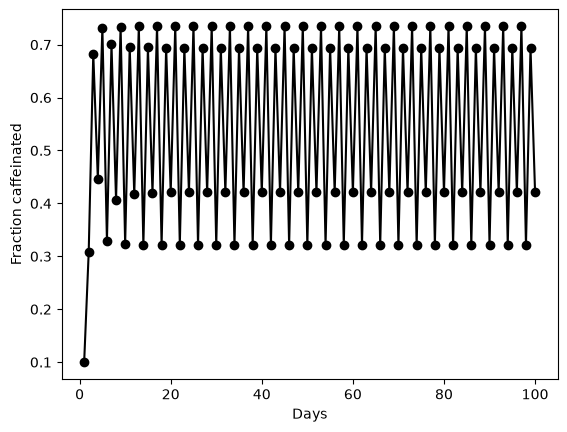

In [4]:
# Your code here.
N = 10  # number of scoops in each jar
r = 2.5 # rate of growth
K = 0.6 # carrying capacity
n_max = 10 * N  # max number of days to simulate

x = np.zeros(n_max)  # fraction caffeinated

x[0] = 0.1

for n in range(1, n_max):

    x[n] = x[n-1] + r*(1-(x[n-1]/K))*x[n-1]

# finished loop through days

days = np.arange(1, n_max + 1)

fig, ax = plt.subplots()
ax.plot(days, x, "-ok")
ax.set_ylabel("Fraction caffeinated")
ax.set_xlabel("Days")
plt.show()

f.  (Optional) Can you find a value of $r$, $K$ and $x(1)$ that gives a
    3-cycle?

In [33]:
def run_sim(r, K, initial_value):

    n_max = 200
    x = np.zeros(n_max)

    x[0] = initial_value

    for n in range(1, n_max):
        x[n] = x[n-1] + r*(1 - x[n-1]/K)*x[n-1]

    # Get last 100 values
    final_50 = x[-100:]

    # Get unique values
    unique_values = np.unique(np.round(final_50, 4))

    return unique_values

In [25]:
run_sim(2.1, 0.6, 0.1)


array([0.494241, 0.677187])

g.  In this part, we will do a parameter sweep for $0<r<3.0$, with fixed
    $K=0.6$. The goal is to generate a diagram where the horizontal axis
    is the parameter value $r$. On the vertical axis, if there is a
    stable steady state, plot the steady-state population. If there is
    an $N$-cycle, plot the $N$ values of $x$ that it cycles through.

Hint: One way to plot the steady state or the $N$-cycle is to simulate
the system until $n_\mathrm{max}$, and plot the last half of the values
of $x(n)$. You need to choose $n_\mathrm{max}$ large enough so that the
dynamics have settled into their steady state (or steady cycle) by
$n_\mathrm{max}/2$.

Hint: How many $r$ values should you explore?

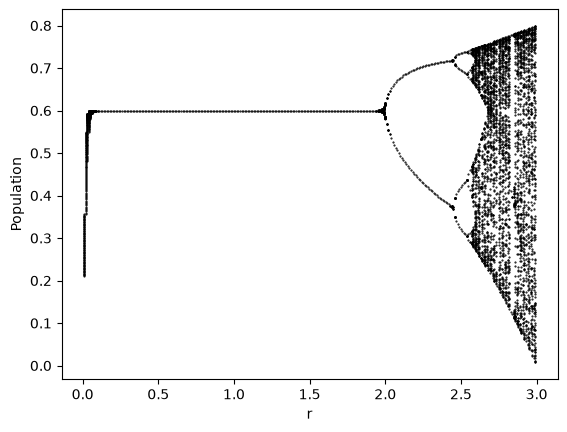

In [39]:
results = []

for i in range(1, 300):

    r_curr = i / 100

    unique_values = run_sim(r_curr, 0.6, 0.1)

    for value in unique_values:
        results.append([r_curr, value])
        
results = np.array(results)

plt.plot(results[:, 0], results[:, 1], ".k", markersize=1)

plt.xlabel("r")
plt.ylabel("Population")
plt.show()

This type of behavior in a dynamical system is called *chaos*! This
particular type of chaos is called period-doubling chaos.